# NONTORNADIC CASE PROCESS

In [1]:
from new_case_functions import *


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



In [2]:
storm_id = 13
meso_id = 1, 11

In [3]:
d = '20220524'
ka = 'ka1'
Ka = 'Ka1'
weights = [0.05, 0.2, 0.5, 0.2, 0.05]

In [4]:
tobac_features_xr_refl = xr.open_dataset(f'/Users/juliabman/Desktop/research2024/tobac_Save/{d}_tobac_Plot/{d}_Track_refl.nc')
tobac_df_refl = tobac_id(tobac_features_xr_refl, storm_id)
latitude_weighted_tobac, longitude_weighted_tobac, storm_bearing, storm_speed, storm_times = storm_speed_and_bearing(tobac_df_refl, weights)

tobac_features_xr_shear = xr.open_dataset(f'/Users/juliabman/Desktop/research2024/tobac_Save/{d}_tobac_Plot/{d}_Track_shear.nc')
tobac_df_shear = tobac_id(tobac_features_xr_shear, meso_id)
latitude_weighted_tobac_meso, longitude_weighted_tobac_meso, meso_bearing, meso_speed, meso_times = storm_speed_and_bearing(tobac_df_shear, weights)

/Users/juliabman/Desktop/research2024/cases/new_case_functions.py:306: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  tobac_times_datetime = tobac_times.astype('datetime64[s]')
/Users/juliabman/Desktop/research2024/cases/new_case_functions.py:306: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArr

In [5]:

#grib_nc = xr.open_dataset(f'/Users/juliabman/Desktop/concat_test/{d}_grib.nc')
#lats, lons, times, shears = azshear_grib_variables(grib_nc)

# data that DOES depend on vads information
vads = sorted(glob.glob(f'/Volumes/Buhrman_4TB/dealiased_data/{d}/{ka}/*.nc'))
print(f'The number of VADs for {d} {Ka} is: {np.shape(vads)} VADs')
gps = pd.read_csv(f'/Volumes/Buhrman_4TB/product_raw/{ka}/GPS_{Ka}_{d}.txt', dtype='str')

easterlies_vads, westerlies_vads, secondtrip_vads = vads_sort(vads, gps)
print(f"""
The number of easterly VADs for {d} {Ka} is: {np.shape(easterlies_vads)} VADs
The number of westerly VADs for {d} {Ka} is: {np.shape(westerlies_vads)} VADs
The number of second trip VADs for {d} {Ka} is: {np.shape(secondtrip_vads)} VADs
""")

The number of VADs for 20220524 Ka1 is: (157,) VADs

The number of easterly VADs for 20220524 Ka1 is: (53,) VADs
The number of westerly VADs for 20220524 Ka1 is: (42,) VADs
The number of second trip VADs for 20220524 Ka1 is: (62,) VADs



In [6]:
vad_times, tobac_times, tobac_indeces, tobac_lats, tobac_lons = nearest_tobac_time(easterlies_vads, 
                                                                               np.array(latitude_weighted_tobac),
                                                                               np.array(longitude_weighted_tobac),
                                                                               storm_times[:-1])
storm_bearing_tobac_vads = storm_bearing[tobac_indeces]
storm_vel_tobac_vads = storm_speed[tobac_indeces]

meso_vad_times, meso_times, meso_indeces, meso_lats, meso_lons = nearest_tobac_time(easterlies_vads, 
                                                                               np.array(latitude_weighted_tobac_meso),
                                                                               np.array(longitude_weighted_tobac_meso),
                                                                               meso_times[:-1])

meso_bearing_tobac_vads = meso_bearing[meso_indeces]
meso_vel_tobac_vads = meso_speed[meso_indeces]

vad_df = vad_df_new(easterlies_vads, gps, vad_times, tobac_times, tobac_indeces, tobac_lats, tobac_lons)

Get the max values over time of the target mesocyclones using the Features_shear dataset.

In [7]:
meso_stats = xr.open_dataset(f'/Users/juliabman/Desktop/research2024/tobac_Save/{d}_tobac_Plot/{d}_Features_shear.nc')

In [8]:
meso_stats

<xarray.Dataset>
Dimensions:          (index: 362)
Coordinates:
  * index            (index) int64 0 1 2 3 4 5 6 ... 355 356 357 358 359 360 361
Data variables: (12/14)
    frame            (index) int64 ...
    idx              (index) int64 ...
    hdim_1           (index) int64 ...
    hdim_2           (index) int64 ...
    num              (index) int64 ...
    threshold_value  (index) int64 ...
    ...               ...
    max              (index) float32 ...
    feature          (index) int64 ...
    time             (index) datetime64[ns] ...
    timestr          (index) <U19 ...
    latitude         (index) float64 ...
    longitude        (index) float64 ...

In [9]:
if not isinstance(meso_id, (list, set)):
    meso_id = [meso_id]
    
    meso_indeces = tobac_features_xr_shear['cell'].where(tobac_features_xr_shear['cell'].isin(meso_id), drop=True)

meso_ids = meso_indeces.index


In [10]:
meso_ids

<xarray.DataArray 'index' (index: 24)>
array([  0,   1,   3,   4,   5,   8,   9,  14,  20,  25,  28,  31,  40,  47,
        57,  70, 100, 104, 163, 175, 194, 207, 220, 331])
Coordinates:
  * index    (index) int64 0 1 3 4 5 8 9 14 ... 100 104 163 175 194 207 220 331

In [11]:
if not isinstance(meso_ids, (list, set)):
    meso_ids = [meso_ids]
    
    meso_indeces2 = meso_stats['idx'].index.where(meso_stats['idx'].index.isin(meso_ids), drop=True)

meso_ids_stats = meso_indeces2.index


In [12]:
meso_ids_stats

<xarray.DataArray 'index' (index: 24)>
array([  0,   1,   3,   4,   5,   8,   9,  14,  20,  25,  28,  31,  40,  47,
        57,  70, 100, 104, 163, 175, 194, 207, 220, 331])
Coordinates:
  * index    (index) int64 0 1 3 4 5 8 9 14 ... 100 104 163 175 194 207 220 331

In [13]:
wanted_meso_max = meso_stats['max'][meso_ids_stats].values

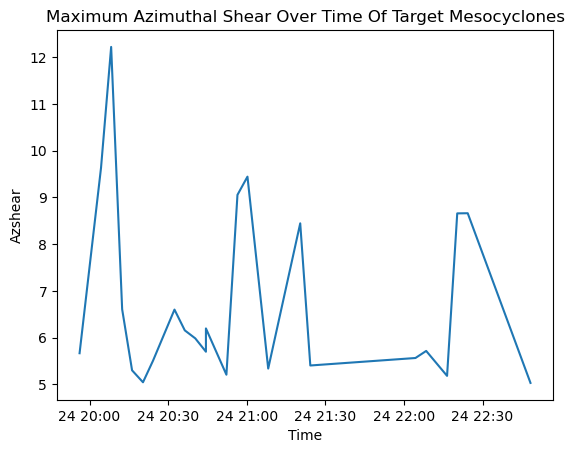

In [14]:
fig = plt.figure()
plt.plot(meso_stats['time'][meso_ids_stats], wanted_meso_max)
plt.title('Maximum Azimuthal Shear Over Time Of Target Mesocyclones')
plt.xlabel('Time')
plt.ylabel('Azshear')
plt.show()

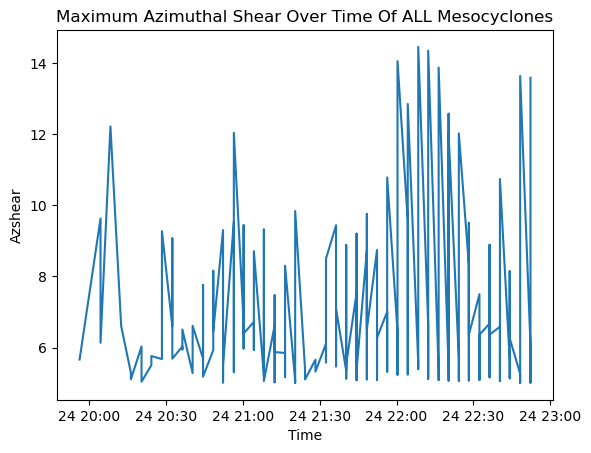

In [15]:
fig = plt.figure()
plt.plot(meso_stats['time'], meso_stats['max'].values)
plt.title('Maximum Azimuthal Shear Over Time Of ALL Mesocyclones')
plt.xlabel('Time')
plt.ylabel('Azshear')
plt.show()

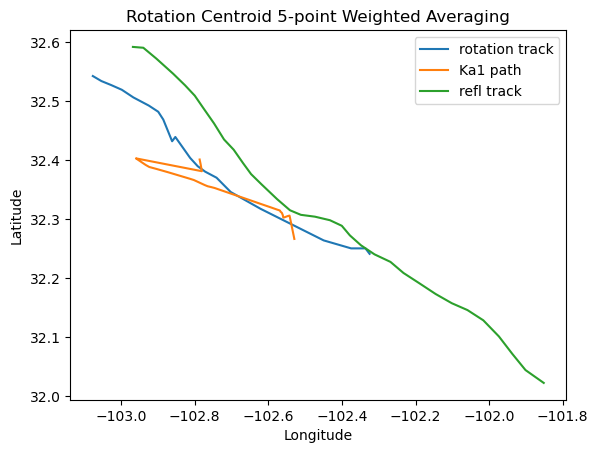

In [16]:
from matplotlib import rcParams, rcParamsDefault
rcParams.update(rcParamsDefault)

fig = plt.figure()
plt.plot(longitude_weighted_tobac_meso, latitude_weighted_tobac_meso)
plt.plot(vad_df.Lonmean, vad_df.Latmean)
#plt.plot(vad_df_ka2.Lonmean, vad_df_ka2.Latmean)
plt.plot(longitude_weighted_tobac, latitude_weighted_tobac)
plt.title('Rotation Centroid 5-point Weighted Averaging')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(['rotation track', f'{Ka} path', 'refl track'])
plt.show()

In [17]:
meso_to_ka_dist= []
meso_to_ka_bear = []
for i in range(len(meso_lats)):
    #print(rot_lats[i])
    fwd_az, back_az, distance = geodesic.inv(vad_df.Lonmean[i], vad_df.Latmean[i], meso_lons[i], meso_lats[i])
    # distance in m, az in degrees clockwise from N
    distance_km = distance / 1000
    meso_to_ka_dist.append(distance_km)
    meso_to_ka_bear.append(fwd_az)
    #storm_bearing_rot.append(fwd_az)

(53,)
(53,)


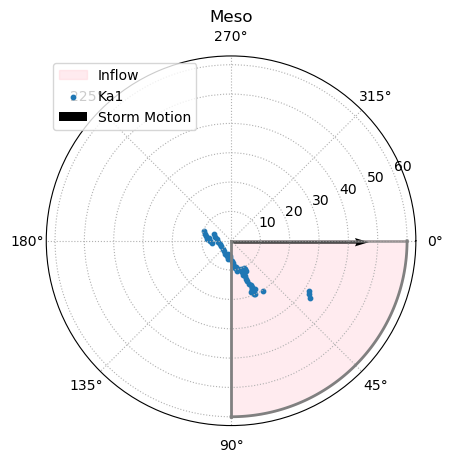

In [18]:
theta, r = polar_plot('Meso', meso_to_ka_bear, storm_bearing_tobac_vads, meso_to_ka_dist, f'{Ka}')

In [19]:
theta_deg = theta * (180/np.pi)

In [25]:
inflow_vads, not_inflow_vads, nearfield_vads, farfield_vads, inflow_column, distance_column = inflow_near_far_test(storm_bearing_tobac_vads, theta_deg, easterlies_vads, meso_to_ka_dist, 90, 0)

6.804280830729473
3
7.659934863464173
4
8.542780531440142
5
9.462394567869406
6
10.391743362640119
7
9.076156747298656
8
9.94531475861951
9
10.334667454462085
10
10.712907826510662
11
11.530102078047852
12
12.475555980211922
13
10.33897039802356
14
11.370255710705042
15
12.247714919497373
16
13.017887154968992
17
13.918829629349926
18
14.877637801877931
19
15.868756325683925
20
16.66159498851696
21
17.358173120868535
22
17.548516215511476
23
17.974807772635426
24
18.35081029777542
25
18.66730983249477
26
19.028548821690283
27
19.598607504333646
28
19.982532634625027
29
20.354249410151866
30
18.517526561217426
31


In [26]:
vad_df['Inflow'] = inflow_column
vad_df['Distance'] = distance_column
vad_df['Angle'] = theta_deg
vad_df['Tor or Nontor'] = 'nontor'

In [27]:
vad_df

,Datetime,Radar,Velmean,Velvar,Bearmean,Latmean,Latvar,Lonmean,Lonvar,tobac_times,tobac_indeces,tobac_lats,tobac_lons,Inflow,Distance,Angle,Tor or Nontor
0,2022-05-24 19:56:34,<pyart.core.radar.Radar object at 0x30c07bc10>,61.522143,7.210972,164.171429,32.401047,1.306443e-06,-102.786662,1.457632e-07,2022-05-24 20:28:09,0,32.591834,-102.968065,Farfield,31.480266,32.965057,nontor
1,2022-05-24 19:57:04,<pyart.core.radar.Radar object at 0x30be9a370>,59.822143,0.321372,164.155000,32.393123,1.243367e-06,-102.784022,1.394118e-07,2022-05-24 20:28:09,0,32.591834,-102.968065,Farfield,32.140599,34.102468,nontor
2,2022-05-24 19:58:04,<pyart.core.radar.Radar object at 0x30b230b50>,23.034286,68.210626,240.270714,32.381258,1.688779e-08,-102.780698,2.563032e-07,2022-05-24 20:28:09,0,32.591834,-102.968065,Farfield,33.102238,35.774842,nontor
3,2022-05-24 20:44:45,<pyart.core.radar.Radar object at 0x11a2e8730>,51.940000,2.832417,116.926923,32.403014,1.839804e-07,-102.959820,9.898181e-07,2022-05-24 20:44:25,4,32.526830,-102.826374,Not in Inflow,9.790840,198.807908,nontor
4,2022-05-24 20:45:15,<pyart.core.radar.Radar object at 0x30be62970>,58.745000,1.269719,116.355000,32.399468,2.585290e-07,-102.951402,1.463505e-06,2022-05-24 20:44:25,4,32.526830,-102.826374,Not in Inflow,9.193909,194.872177,nontor
5,2022-05-24 20:45:45,<pyart.core.radar.Radar object at 0x30c07b850>,61.680769,0.164341,116.351538,32.395749,2.440142e-07,-102.942562,1.387363e-06,2022-05-24 20:44:25,4,32.526830,-102.826374,Not in Inflow,8.619881,190.179690,nontor
6,2022-05-24 20:46:15,<pyart.core.radar.Radar object at 0x30c07a4c0>,63.030714,0.032330,116.437857,32.391828,2.938540e-07,-102.933211,1.664981e-06,2022-05-24 20:44:25,4,32.526830,-102.826374,Not in Inflow,8.083858,184.539661,nontor
7,2022-05-24 20:46:46,<pyart.core.radar.Radar object at 0x30bed18e0>,63.205385,0.025010,103.043846,32.388384,5.862247e-08,-102.923487,1.727878e-06,2022-05-24 20:48:40,5,32.509265,-102.799954,Not in Inflow,7.575985,186.308346,nontor
8,2022-05-24 20:47:15,<pyart.core.radar.Radar object at 0x30b4cde80>,63.669231,0.020758,101.402308,32.386715,5.094993e-08,-102.913612,1.771455e-06,2022-05-24 20:48:40,5,32.509265,-102.799954,Not in Inflow,7.017787,180.295073,nontor
9,2022-05-24 20:47:44,<pyart.core.radar.Radar object at 0x30c0a5a90>,63.649286,0.006115,101.310000,32.385013,5.753950e-08,-102.903561,2.038942e-06,2022-05-24 20:48:40,5,32.509265,-102.799954,Not in Inflow,6.542562,173.199663,nontor


In [28]:
vad_df.to_csv(f'case_dfs/new/{d}_{ka}_vad_df.csv', index=False)

In [29]:
np.shape(nearfield_vads)

(29,)

In [30]:
original_list = nearfield_vads
nearfield_vads = list(dict.fromkeys(original_list))

In [31]:
np.shape(farfield_vads)

(3,)

In [32]:
og = farfield_vads
farfield_vads = list(dict.fromkeys(og))

In [33]:
np.shape(nearfield_vads)

(29,)

In [34]:
np.shape(farfield_vads)

(3,)

In [35]:
nearfield_vad_times, nearfield_times, nearfield_indeces, nearfield_lats, nearfield_lons = nearest_tobac_time(nearfield_vads, 
                                                                                       np.array(latitude_weighted_tobac),
                                                                                       np.array(longitude_weighted_tobac),
                                                                                       storm_times[:-1])

In [36]:
nearfield_bearing = storm_bearing[nearfield_indeces]
nearfield_velocity = storm_speed[nearfield_indeces]

In [37]:
farfield_vad_times, farfield_times, farfield_indeces, farfield_lats, farfield_lons = nearest_tobac_time(farfield_vads, 
                                                                                       np.array(latitude_weighted_tobac),
                                                                                       np.array(longitude_weighted_tobac),
                                                                                       storm_times[:-1])

In [38]:
farfield_bearing = storm_bearing[farfield_indeces]
farfield_velocity = storm_speed[farfield_indeces]

In [39]:
nearfield_u, nearfield_v, nearfield_heights = composite_u_and_v(nearfield_vads, gps, nearfield_velocity, nearfield_bearing)

In [40]:
farfield_u, farfield_v, farfield_heights = composite_u_and_v(farfield_vads, gps, farfield_velocity, farfield_bearing)

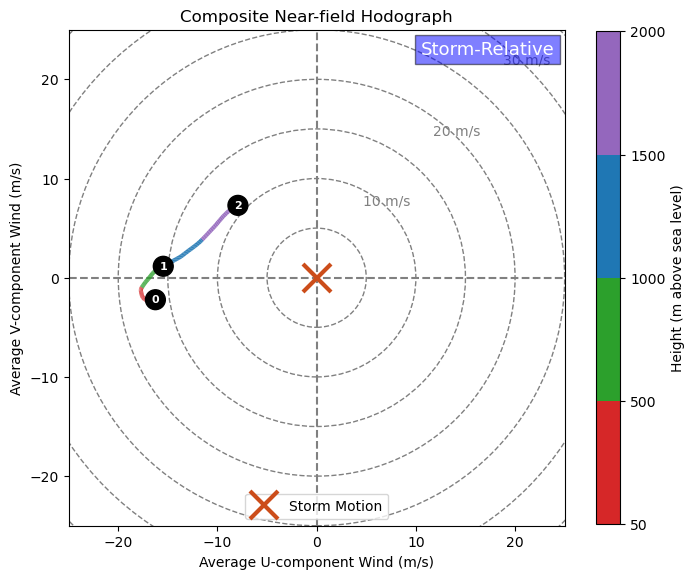

In [41]:
hodo_plot(nearfield_u, nearfield_v, nearfield_heights, 25, 'Composite Near-field Hodograph',['tab:red', 'tab:green', 'tab:blue', 'tab:purple'])

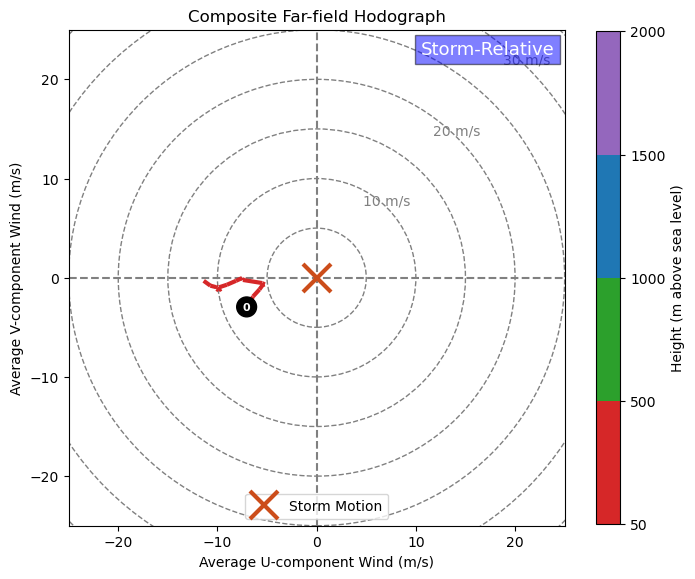

In [42]:
hodo_plot(farfield_u, farfield_v, farfield_heights, 25, 'Composite Far-field Hodograph',['tab:red', 'tab:green', 'tab:blue', 'tab:purple'])

In [43]:
all_nearfield_u, all_nearfield_v = u_and_v(nearfield_vads, gps, nearfield_velocity, nearfield_bearing)

In [44]:
all_farfield_u, all_farfield_v = u_and_v(farfield_vads, gps, farfield_velocity, farfield_bearing)

In [45]:
# Add a label to each variable
def add_label(data, label):
    return pd.DataFrame(data).assign(Variable=label)

In [47]:
np.shape(nearfield_u)

(196,)

In [48]:
columns = ['NFNonToru', 'NFNonTorv', 'FFNonToru', 'FFNonTorv']
comp_data_uv = [nearfield_u, nearfield_v, farfield_u, farfield_v]

comp_field_uv_df = pd.DataFrame(comp_data_uv)
comp_field_uv_df['Variable'] = columns 

In [49]:
np.shape(comp_data_uv)

(4, 196)

In [50]:
comp_field_uv_df

,0,1,2,3,4,5,6,7,8,9,...,187,188,189,190,191,192,193,194,195,Variable
0,-16.254395,-16.366669,-16.462334,-16.544302,-16.724920,-16.808191,-16.929108,-17.047308,-17.142893,-17.219728,...,-8.515774,-8.439775,-8.370627,-8.294908,-8.216820,-8.144752,-8.073379,-7.999704,-7.938176,NFNonToru
1,-2.216187,-2.222924,-2.229680,-2.235221,-2.246284,-2.246999,-2.252052,-2.249460,-2.239878,-2.222196,...,7.003036,7.056075,7.097357,7.142846,7.180676,7.212996,7.242518,7.269532,7.294878,NFNonTorv
2,-7.058154,-6.645177,-6.416524,-6.407792,-5.767850,-5.767850,-5.445766,-5.235015,-5.473639,-7.433238,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FFNonToru
3,-2.941714,-2.296595,-1.909518,-1.886880,-1.186878,-1.186878,-0.740570,-0.676164,-0.540523,-0.224577,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FFNonTorv


In [51]:
comp_field_uv_df.to_csv(f'case_dfs/new/{d}_uv_{ka}.csv', index=False)

In [52]:
columns = ['NFNonToru', 'NFNonTorv', 'FFNonToru', 'FFNonTorv']
data_uv = [all_nearfield_u, all_nearfield_v, all_farfield_u, all_farfield_v]

In [53]:
dfs = []
for v, name in zip(data_uv, columns):
    df = add_label(v, name)
    dfs.append(df)

In [54]:
df_uv = pd.concat([dfs[0], dfs[1], dfs[2], dfs[3]], ignore_index=True)

In [55]:
df_uv

,0,1,2,3,4,5,6,7,8,9,...,187,188,189,190,191,192,193,194,195,Variable
0,-15.059009,-15.087041,-15.095438,-15.102798,-15.152193,-15.144789,-15.131898,-15.105986,-15.085956,-15.073692,...,-3.227107,-3.023806,-2.907731,-2.683585,-2.443737,-2.199413,-1.949040,-1.692158,-1.554429,NFNonToru
1,-17.070499,-17.124611,-17.160816,-17.187227,-17.257687,-17.281158,-17.340485,-17.394985,-17.449574,-17.511360,...,-5.588122,-5.374824,-5.276644,-5.068414,-4.858746,-4.654746,-4.452815,-4.244253,-4.143450,NFNonToru
2,-15.857342,-15.868773,-15.887116,-15.914820,-15.966655,-16.001476,-16.070950,-16.159866,-16.272451,-16.403431,...,-6.969767,-6.791006,-6.603521,-6.434891,-6.269275,-6.105132,-6.007212,-5.847472,-5.711282,NFNonToru
3,-15.887701,-15.989468,-16.064049,-16.135780,-16.302067,-16.368515,-16.512863,-16.638451,-16.751829,-16.867813,...,-8.336829,-8.235676,-8.130974,-8.021487,-7.899228,-7.755897,-7.692513,-7.533483,-7.367861,NFNonToru
4,-17.207933,-17.220028,-17.234020,-17.248678,-17.292492,-17.294970,-17.275826,-17.235554,-17.184143,-17.103237,...,-6.862328,-6.741896,-6.643327,-6.553364,-6.459720,-6.417543,-6.331083,-6.249290,-6.170813,NFNonToru
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,-4.653027,-4.653027,-4.653027,-4.653027,-4.653027,-4.653027,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FFNonToru
60,-8.182272,-6.981166,-6.242469,-6.242469,-4.674619,-4.674619,-3.306886,-3.332765,-3.287683,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FFNonToru
61,-1.735206,-1.637033,-1.571247,-1.503334,-1.450091,-1.450091,-0.935204,-0.729724,-0.441284,-0.224577,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FFNonTorv
62,0.864245,0.864245,0.864245,0.864245,0.864245,0.864245,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FFNonTorv


In [56]:
field_uv_all_df = pd.DataFrame(df_uv)
field_uv_all_df.to_csv(f'case_dfs/new/{d}_uv_{ka}_all.csv', index=False)

In [ ]:
for i in nearfield_vads[:10]: 
    fig = plt.figure(figsize=(20,10))
    read = pyart.io.read(i)
    print(i[-15:-3])
    time = i[-15:-3]
    #print(f'vehicle speed was {ka2_df.Velmean[i]}')
    radar = read.extract_sweeps([0])
    radar, _, _, _, _, _, _, _, _ = vehicle_correction_vad(radar, gps)
    display = pyart.graph.RadarMapDisplay(radar)
    ax1 = fig.add_subplot(2,4,1, projection = display.grid_projection)
    display.plot_ppi_map('reflectivity', ax = ax1, vmin = -30, vmax = 30)
    ax1.set_title('Reflectivity')
    ax2 = fig.add_subplot(2,4,2, projection = display.grid_projection)
    display.plot_ppi_map('vad_corrected_velocity', ax = ax2, 
                         vmin = -40, vmax = 40, cmap = 'pyart_balance')
    display.plot_range_ring(2)
    ax2.set_title('Vehicle Corrected Velocity')
    ax3 = fig.add_subplot(2,4,3, projection = display.grid_projection)
    display.plot_ppi_map('spectrum_width', ax = ax3, cmap = 'cubehelix_r', vmin = 0, vmax = 10)
    ax3.set_title('Spectrum Width')
    ax4 = fig.add_subplot(2,4,4, projection = display.grid_projection)
    ax4.set_xlabel('U-component Wind [knots]')
    ax4.set_ylabel('V-component Wind [knots]')
    ax4.set_title('Vehicle motion corrected VAD')
    VAD = pyart.retrieve.vad_browning(radar, 'vad_corrected_velocity', z_want=np.arange(50,2001,10),gatefilter=None)
    vadu = VAD.u_wind*1.94384 # meters to knots
    vadv = VAD.v_wind*1.94384
    hodo = metpy.plots.Hodograph(ax4, component_range=60.)
    hodo.add_grid(increment=5)
    hodo.plot(vadu, vadv)
    plt.suptitle(f'ka2 Refl, Vr, Spectrum Width at {time}')
    plt.show()